# Komparasi Model Klasifikasi Kualitas Udara

Bandingkan metode klasifikasi:
1. **Breakpoint ISPU** (baseline rule-based)
2. **Random Forest**
3. **XGBoost** (gradient boosting)
4. **LightGBM** (gradient boosting, lebih cepat)

Dataset: KLHK + sensor + sintetis (improved)
Class weight: balanced semua model + sample_weight dari inverse class frequency
Perbaikan dari versi sebelumnya:
1. Filter noise CO (CO > 30000 + PM2.5 < 55 = sensor error) — 32% data sensor terfilter
2. Synthetic data: per-class covariance + boundary overlap untuk realisme
3. Per-class evaluation: F1/precision/recall per kelas ditampilkan
4. Normalized confusion matrix: recall per class (bukan raw count doang)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import joblib, os, time
from supabase import create_client, Client
from datetime import datetime, timedelta

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("Setup done")

Setup done


### Load Dataset (sama dengan train_classification.ipynb)

In [2]:
SUPABASE_URL = os.getenv("SUPABASE_URL", "")
SUPABASE_KEY = os.getenv("SUPABASE_KEY", "")

if not SUPABASE_URL or not SUPABASE_KEY:
    env_path = ".env"
    if os.path.exists(env_path):
        for line in open(env_path):
            if "=" in line and not line.startswith("#"):
                k, _, v = line.partition("=")
                os.environ[k.strip()] = v.strip().strip(chr(34))
    SUPABASE_URL = os.getenv("SUPABASE_URL", "")
    SUPABASE_KEY = os.getenv("SUPABASE_KEY", "")

SUPABASE_URL = SUPABASE_URL.replace("http://", "https://")
supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)

KLHK_DIR = "../klhk/"
FILES = [
    "Filedata Indeks Standar Pencemaran Udara (ISPU) Tahun 2011.csv",
    "Filedata Indeks Standar Pencemaran Udara (ISPU) Tahun 2012.csv",
    "Filedata Indeks Standar Pencemaran Udara (ISPU) Tahun 2013.csv",
    "Filedata Indeks Standar Pencemaran Udara (ISPU) Tahun 2015.csv",
    "Filedata Data Indeks Standar Pencemaran Udara DKI Jakarta Tahun 2017.csv",
    "Filedata Indeks Standar Pencemaran Udara (ISPU) Tahun 2019.csv",
    "Filedata Indeks Standar Pencemaran Udara (ISPU) Tahun 2020.csv",
    "Filedata Indeks Standar Pencemaran Udara (ISPU) Tahun 2022.csv",
]

all_dfs = []
for f in FILES:
    path = os.path.join(KLHK_DIR, f)
    if not os.path.exists(path):
        print(f"SKIP: {f}")
        continue
    all_dfs.append(pd.read_csv(path))

if len(all_dfs) == 0:
    print("WARNING: No KLHK files found, using empty df_klhk")
    raw = pd.DataFrame()
else:
    raw = pd.concat(all_dfs, ignore_index=True)
print(f"KLHK raw: {len(raw)} baris")

LABEL_MAP = {
    "BAIK": "Baik", "SEDANG": "Sedang", "TIDAK SEHAT": "Tidak Sehat",
    "SANGAT TIDAK SEHAT": "Sangat Tidak Sehat", "BERBAHAYA": "Berbahaya",
}

def ispi_to_conc(ispi, bp):
    if ispi <= 0: return 0
    for cl, ch, il, ih in bp:
        if ispi <= ih: return cl + (ispi - il) / (ih - il) * (ch - cl)
    return bp[-1][1]

BP_PM25 = [(0,15.5,0,50),(15.5,55.4,50,100),(55.4,150.4,100,200),(150.4,250.4,200,300),(250.4,500,300,500)]
BP_PM10 = [(0,50,0,50),(50,150,50,100),(150,350,100,200),(350,420,200,300),(420,500,300,500)]
BP_CO   = [(0,4000,0,50),(4000,8000,50,100),(8000,15000,100,200),(15000,30000,200,300),(30000,45000,300,500)]
BP_NO2  = [(0,80,0,50),(80,200,50,100),(200,1130,100,200),(1130,2260,200,300),(2260,3000,300,500)]
BP_O3   = [(0,120,0,50),(120,235,50,100),(235,400,100,200),(400,800,200,300),(800,1000,300,500)]

klhk_rows = []
for _, r in raw.iterrows():
    cat_col = "kategori" if "kategori" in raw.columns and "categori" not in raw.columns else "categori"
    if cat_col not in r or pd.isna(r.get(cat_col)): continue
    label = LABEL_MAP.get(str(r[cat_col]).strip().upper())
    if not label: continue
    pm10_ispi = pd.to_numeric(r.get("pm10", r.get("pm_10", 0)), errors="coerce")
    co_ispi   = pd.to_numeric(r.get("co", 0), errors="coerce")
    o3_ispi   = pd.to_numeric(r.get("o3", 0), errors="coerce")
    no2_ispi  = pd.to_numeric(r.get("no2", 0), errors="coerce")
    pm25_ispi = pd.to_numeric(r.get("pm_duakomalima"), errors="coerce") if pd.notna(r.get("pm_duakomalima")) else pm10_ispi * 0.7
    pm25 = ispi_to_conc(pm25_ispi if pd.notna(pm25_ispi) else 0, BP_PM25)
    pm10 = ispi_to_conc(pm10_ispi if pd.notna(pm10_ispi) else 0, BP_PM10)
    co   = ispi_to_conc(co_ispi if pd.notna(co_ispi) else 0, BP_CO)
    no2  = ispi_to_conc(no2_ispi if pd.notna(no2_ispi) else 0, BP_NO2)
    o3 = ispi_to_conc(o3_ispi if pd.notna(o3_ispi) else 0, BP_O3)
    if pm25 > 0 and pm10 > 0:
        klhk_rows.append({"PM2.5": pm25, "PM10": pm10, "CO": co, "NO2": no2, "O3": o3, "Label": label, "src": "klhk"})

df_klhk = pd.DataFrame(klhk_rows)
print(f"KLHK clean: {len(df_klhk)} baris")

SKIP: Filedata Indeks Standar Pencemaran Udara (ISPU) Tahun 2011.csv
SKIP: Filedata Indeks Standar Pencemaran Udara (ISPU) Tahun 2012.csv
SKIP: Filedata Indeks Standar Pencemaran Udara (ISPU) Tahun 2013.csv
SKIP: Filedata Indeks Standar Pencemaran Udara (ISPU) Tahun 2015.csv
SKIP: Filedata Data Indeks Standar Pencemaran Udara DKI Jakarta Tahun 2017.csv
SKIP: Filedata Indeks Standar Pencemaran Udara (ISPU) Tahun 2019.csv
SKIP: Filedata Indeks Standar Pencemaran Udara (ISPU) Tahun 2020.csv
SKIP: Filedata Indeks Standar Pencemaran Udara (ISPU) Tahun 2022.csv
KLHK raw: 0 baris
KLHK clean: 0 baris


In [3]:
# Try Supabase first, fallback to local CSV
CSV_FALLBACK = '../data_train/tb_konsentrasi_gas.csv'
TABLE = "tb_konsentrasi_gas"
since = (datetime.utcnow() - timedelta(days=90)).isoformat()
all_data, offset, supabase_ok = [], 0, True
try:
    while True:
        resp = supabase.table(TABLE) \
            .select("pm25_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,o3_ugm3") \
            .gte("created_at", since).order("created_at", desc=False).range(offset, offset+999).execute()
        if not resp.data: break
        all_data.extend(resp.data)
        offset += len(resp.data)
except Exception as e:
    print(f"Supabase failed: {e}, falling back to CSV: {CSV_FALLBACK}")
    supabase_ok = False

if supabase_ok and len(all_data) > 0:
    df_sensor = pd.DataFrame(all_data)
elif os.path.exists(CSV_FALLBACK):
    df_sensor = pd.read_csv(CSV_FALLBACK)
else:
    df_sensor = pd.DataFrame()
    print("WARNING: No sensor data available from either Supabase or CSV")
for c in ["pm25_ugm3","pm10_ugm3","co_ugm3","no2_ugm3","o3_ugm3"]:
    df_sensor[c] = pd.to_numeric(df_sensor[c], errors="coerce")
df_sensor = df_sensor.dropna(subset=["pm25_ugm3","pm10_ugm3","o3_ugm3"])

def conc_to_ispi(val, bp):
    if val <= 0: return 0
    for cl, ch, il, ih in bp:
        if val <= ch: return il + (val - cl) / (ch - cl) * (ih - il)
    return bp[-1][3]

def ispi_to_label(ispi):
    if ispi <= 50: return "Baik"
    if ispi <= 100: return "Sedang"
    if ispi <= 200: return "Tidak Sehat"
    if ispi <= 300: return "Sangat Tidak Sehat"
    return "Berbahaya"

sensor_rows = []
for _, r in df_sensor.iterrows():
    pm25, pm10, co, no2 = r["pm25_ugm3"], r["pm10_ugm3"], r["co_ugm3"], r["no2_ugm3"]
    o3_ugm3 = r["o3_ugm3"]
    ispis = [conc_to_ispi(pm25,BP_PM25), conc_to_ispi(pm10,BP_PM10), conc_to_ispi(co,BP_CO), conc_to_ispi(no2,BP_NO2), conc_to_ispi(o3_ugm3,BP_O3)]
    label = ispi_to_label(max(ispis))
    sensor_rows.append({"PM2.5": pm25, "PM10": pm10, "CO": co, "NO2": no2, "O3": o3_ugm3, "Label": label, "src": "sensor"})

df_sensor_raw = pd.DataFrame(sensor_rows)
print(f"\nSensor sebelum filter: {len(df_sensor_raw)} baris")
print("Distribusi label (sebelum filter):")
print(df_sensor_raw['Label'].value_counts().to_string())

# --- Filter noise CO: CO > 30000 tapi PM2.5 < 55 = sensor error ---
noise_mask = (df_sensor_raw['CO'] > 30000) & (df_sensor_raw['PM2.5'] < 55)
print(f"\nTerdeteksi noise CO (CO>30000 & PM2.5<55): {noise_mask.sum()} baris")
df_sensor_clean = df_sensor_raw[~noise_mask].copy()
print(f"Sensor setelah filter noise: {len(df_sensor_clean)} baris")
print("Distribusi label (setelah filter):")
print(df_sensor_clean['Label'].value_counts().to_string())


Sensor sebelum filter: 80122 baris
Distribusi label (sebelum filter):
Label
Sedang                40494
Baik                  39406
Berbahaya               183
Tidak Sehat              38
Sangat Tidak Sehat        1

Terdeteksi noise CO (CO>30000 & PM2.5<55): 5 baris
Sensor setelah filter noise: 80117 baris
Distribusi label (setelah filter):
Label
Sedang                40494
Baik                  39406
Berbahaya               178
Tidak Sehat              38
Sangat Tidak Sehat        1


In [4]:
FEATURES = ["PM2.5", "PM10", "CO", "NO2", "O3"]
FEAT_KEYS = ['pm25_ugm3','pm10_ugm3','co_ugm3','no2_ugm3','o3_ugm3']
np.random.seed(42)

SYNTH_RANGES = {
    "Baik": [(1,14), (5,48), (200,4800), (1,38), (2,108)],
    "Sedang": [(16,34), (51,148), (5100,9800), (41,78), (120,234)],
    "Tidak Sehat": [(36,54), (151,348), (10100,16800), (81,178), (236,399)],
    "Sangat Tidak Sehat": [(56,149), (351,419), (17100,33800), (181,279), (401,799)],
    "Berbahaya": [(151,350), (421,550), (34100,50000), (281,500), (801,1000)],
}

# Compute per-class corr from real data (KLHK+sensor after noise filter)
df_real = pd.concat([df_klhk, df_sensor_clean], ignore_index=True)

def nearest_posdef(A):
    eigvals, eigvecs = np.linalg.eigh(A)
    eigvals = np.maximum(eigvals, 1e-6)
    return eigvecs @ np.diag(eigvals) @ eigvecs.T

per_class_corr = {}
for lbl in ['Baik','Sedang','Tidak Sehat','Sangat Tidak Sehat','Berbahaya']:
    sub = df_real[df_real['Label'] == lbl]
    if len(sub) >= 20:
        c = sub[FEATURES].corr().fillna(0).values
        per_class_corr[lbl] = nearest_posdef(c)
    else:
        per_class_corr[lbl] = np.eye(5)

synth_rows = []
N_SYNTH = {'Baik': 600, 'Sedang': 600, 'Tidak Sehat': 1200,
           'Sangat Tidak Sehat': 1200, 'Berbahaya': 1200}
BOUNDARY_FRAC = 0.3

for label, ranges in SYNTH_RANGES.items():
    n = N_SYNTH[label]
    n_boundary = int(n * BOUNDARY_FRAC)
    n_center = n - n_boundary
    means = [(lo+hi)/2 for lo,hi in ranges]
    stds = [(hi-lo)/4 for lo,hi in ranges]
    bounds = [(lo,hi) for lo,hi in ranges]
    D = np.diag(stds)
    cov = D @ per_class_corr[label] @ D
    cov = nearest_posdef(cov)

    # Center samples (near midpoint)
    try:
        center_samp = np.random.multivariate_normal(means, cov, n_center)
    except np.linalg.LinAlgError:
        center_samp = np.random.multivariate_normal(means, cov + np.eye(5)*1e-6, n_center)

    # Boundary samples (near low/high edges for realism/overlap)
    boundary_samp = []
    for _ in range(n_boundary):
        edge_means = []
        for lo, hi in ranges:
            if np.random.rand() < 0.5:
                edge_means.append(lo + (hi-lo)*0.1)
            else:
                edge_means.append(hi - (hi-lo)*0.1)
        try:
            s = np.random.multivariate_normal(edge_means, cov*0.5, 1)[0]
        except np.linalg.LinAlgError:
            s = np.random.multivariate_normal(edge_means, np.eye(5)*10, 1)[0]
        boundary_samp.append(s)
    boundary_samp = np.array(boundary_samp) if boundary_samp else np.empty((0,5))

    samples = np.vstack([center_samp, boundary_samp]) if len(boundary_samp) else center_samp
    for i in range(len(FEATURES)):
        lo, hi = bounds[i]
        samples[:, i] = np.clip(samples[:, i], lo, hi)
    for i in range(len(samples)):
        row = {feat: float(samples[i,j]) for j,feat in enumerate(FEATURES)}
        row["Label"] = label
        row["src"] = "synthetic"
        synth_rows.append(row)

df_synth = pd.DataFrame(synth_rows)
print(f"Sintetis: {len(df_synth)} baris")

Sintetis: 4800 baris


In [5]:
df_all = pd.concat([df_klhk, df_sensor_clean, df_synth], ignore_index=True)
FEATURES = ["PM2.5", "PM10", "CO", "NO2", "O3"]
LABELS = ["Baik", "Sedang", "Tidak Sehat", "Sangat Tidak Sehat", "Berbahaya"]

X = df_all[FEATURES]
y = df_all["Label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Dataset: {len(df_all)} baris")
print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"\nDistribusi label:")
print(y.value_counts().to_string())

# --- Breakpoint ISPU baseline ---
y_pred_bp = []
for _, row in X_test.iterrows():
    pm25, pm10, co_val, no2, o3 = row['PM2.5'], row['PM10'], row['CO'], row['NO2'], row['O3']
    ispis = [
        conc_to_ispi(pm25, BP_PM25),
        conc_to_ispi(pm10, BP_PM10),
        conc_to_ispi(co_val, BP_CO),
        conc_to_ispi(no2, BP_NO2),
        conc_to_ispi(o3, BP_O3),
    ]
    y_pred_bp.append(ispi_to_label(max(ispis)))
y_pred_bp = pd.Series(y_pred_bp, index=y_test.index)
print("\nBreakpoint ISPU baseline siap")

Dataset: 84917 baris
Train: 63687, Test: 21230

Distribusi label:
Label
Sedang                41094
Baik                  40006
Berbahaya              1378
Tidak Sehat            1238
Sangat Tidak Sehat     1201



Breakpoint ISPU baseline siap


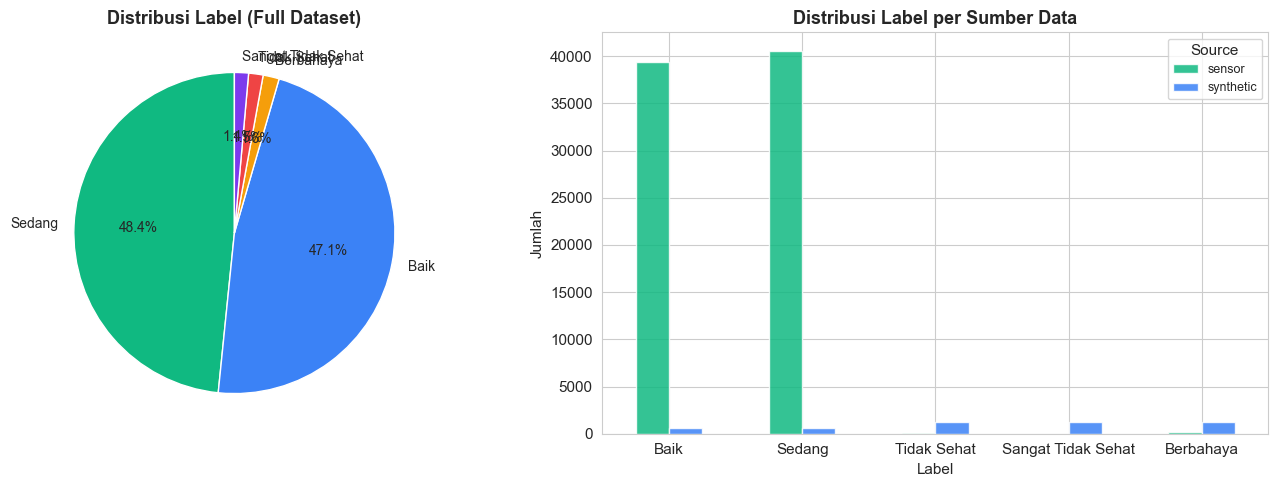

Saved: class_distribution.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart distribusi label
counts = y.value_counts()
colors_pie = ['#10b981', '#3b82f6', '#f59e0b', '#ef4444', '#7c3aed']
axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors_pie[:len(counts)], startangle=90, textprops={'fontsize': 10})
axes[0].set_title('Distribusi Label (Full Dataset)', fontsize=13, fontweight='bold')

# Bar chart per source
src_counts = df_all.groupby(['src', 'Label']).size().unstack(fill_value=0)
src_counts = src_counts[LABELS]  # ensure all labels present
src_counts.T.plot(kind='bar', ax=axes[1], color=colors_pie[:len(src_counts)], alpha=0.85, edgecolor='white')
axes[1].set_title('Distribusi Label per Sumber Data', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Label', fontsize=11)
axes[1].set_ylabel('Jumlah', fontsize=11)
axes[1].legend(title='Source', fontsize=9)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: class_distribution.png")

In [7]:
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
le = LabelEncoder()
le.fit(LABELS)
y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)

# Class weights untuk menangani imbalance
class_weights = compute_class_weight('balanced', classes=np.array(LABELS), y=y_train)
sample_weights = np.array([class_weights[le.transform([l])[0]] for l in y_train])
print(f"Class weights: {dict(zip(LABELS, class_weights.round(2)))}")

RF = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced", n_jobs=-1)
XGB = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric="mlogloss", verbosity=0)
LGBM = __import__('lightgbm', fromlist=['LGBMClassifier']).LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, class_weight="balanced", verbosity=-1, n_jobs=-1)

MODELS = {"Random Forest": RF, "XGBoost": XGB, "LightGBM": LGBM}

print("Model defined (labels encoded):", list(le.classes_))

Class weights: {'Baik': np.float64(0.42), 'Sedang': np.float64(0.41), 'Tidak Sehat': np.float64(13.71), 'Sangat Tidak Sehat': np.float64(14.14), 'Berbahaya': np.float64(12.33)}
Model defined (labels encoded): [np.str_('Baik'), np.str_('Berbahaya'), np.str_('Sangat Tidak Sehat'), np.str_('Sedang'), np.str_('Tidak Sehat')]


### Train & Evaluate Semua Model

In [8]:
results = []
trained_models = {}

def get_per_class_metrics(y_true, y_pred, labels):
    report = classification_report(y_true, y_pred, target_names=labels, output_dict=True, zero_division=0)
    return {l: {'precision': report[l]['precision'], 'recall': report[l]['recall'],
                'f1': report[l]['f1-score'], 'support': report[l]['support']} for l in labels}

# Breakpoint ISPU baseline
acc_bp = accuracy_score(y_test, y_pred_bp)
prec_w_bp = precision_score(y_test, y_pred_bp, average='weighted', zero_division=0)
rec_w_bp  = recall_score(y_test, y_pred_bp, average='weighted', zero_division=0)
f1_w_bp   = f1_score(y_test, y_pred_bp, average='weighted', zero_division=0)
prec_m_bp = precision_score(y_test, y_pred_bp, average='macro', zero_division=0)
rec_m_bp  = recall_score(y_test, y_pred_bp, average='macro', zero_division=0)
f1_m_bp   = f1_score(y_test, y_pred_bp, average='macro', zero_division=0)
cm_bp = confusion_matrix(y_test, y_pred_bp, labels=LABELS)
per_class_bp = get_per_class_metrics(y_test, y_pred_bp, LABELS)

results.append({
    "Model": "Breakpoint ISPU",
    "Accuracy": round(acc_bp*100, 2),
    "Precision_W": round(prec_w_bp*100, 2),
    "Recall_W": round(rec_w_bp*100, 2),
    "F1_W": round(f1_w_bp*100, 2),
    "Precision_M": round(prec_m_bp*100, 2),
    "Recall_M": round(rec_m_bp*100, 2),
    "F1_M": round(f1_m_bp*100, 2),
    "Train_time": 0,
    "CM": cm_bp,
    "PerClass": per_class_bp,
})
print('---')
print('Breakpoint ISPU (baseline):')
print(f"  Accuracy:  {acc_bp*100:.2f}%")
print(f"  F1 (macro): {f1_m_bp*100:.2f}%")
print("  Per-class F1:")
for lbl in LABELS:
    p = per_class_bp[lbl]
    print(f"    {lbl:20s}  prec={p['precision']*100:.1f}%  recall={p['recall']*100:.1f}%  f1={p['f1']*100:.1f}%  n={int(p['support'])}")
print()

for name, model in MODELS.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print('='*50)

    t0 = time.time()
    if name in ("XGBoost", "LightGBM"):
        model.fit(X_train, y_train_enc, sample_weight=sample_weights)
        y_pred = le.inverse_transform(model.predict(X_test))
        y_proba = model.predict_proba(X_test)
    else:
        model.fit(X_train, y_train, sample_weight=sample_weights)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)
    train_time = time.time() - t0

    acc = accuracy_score(y_test, y_pred)
    prec_w = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec_w  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_w   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    prec_m = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec_m  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_m   = f1_score(y_test, y_pred, average='macro', zero_division=0)

    cm = confusion_matrix(y_test, y_pred, labels=LABELS)
    per_class = get_per_class_metrics(y_test, y_pred, LABELS)

    results.append({
        "Model": name,
        "Accuracy": round(acc*100, 2),
        "Precision_W": round(prec_w*100, 2),
        "Recall_W": round(rec_w*100, 2),
        "F1_W": round(f1_w*100, 2),
        "Precision_M": round(prec_m*100, 2),
        "Recall_M": round(rec_m*100, 2),
        "F1_M": round(f1_m*100, 2),
        "Train_time": round(train_time, 3),
        "CM": cm,
        "PerClass": per_class,
    })

    trained_models[name] = model

    print(f"  Accuracy:  {acc*100:.2f}%")
    print(f"  Precision (weighted): {prec_w*100:.2f}%")
    print(f"  Recall (weighted):    {rec_w*100:.2f}%")
    print(f"  F1 (weighted):       {f1_w*100:.2f}%")
    print(f"  F1 (macro):          {f1_m*100:.2f}%")
    print(f"  Train time:          {train_time:.3f}s")
    print("  Per-class F1:")
    for lbl in LABELS:
        p = per_class[lbl]
        print(f"    {lbl:20s}  prec={p['precision']*100:.1f}%  recall={p['recall']*100:.1f}%  f1={p['f1']*100:.1f}%  n={int(p['support'])}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=LABELS, zero_division=0))

df_results = pd.DataFrame(results).drop(columns=['CM', 'PerClass'])
print("\n\n" + "="*60)
print("RINGKASAN PERBANDINGAN MODEL")
print("="*60)
print(df_results.to_string(index=False))

---
Breakpoint ISPU (baseline):
  Accuracy:  98.99%
  F1 (macro): 89.58%
  Per-class F1:
    Baik                  prec=100.0%  recall=99.8%  f1=99.9%  n=10002
    Sedang                prec=83.1%  recall=100.0%  f1=90.8%  n=345
    Tidak Sehat           prec=78.2%  recall=76.7%  f1=77.4%  n=300
    Sangat Tidak Sehat    prec=99.8%  recall=99.4%  f1=99.6%  n=10274
    Berbahaya             prec=81.1%  recall=79.3%  f1=80.2%  n=309


Training Random Forest...


  Accuracy:  99.99%
  Precision (weighted): 99.99%
  Recall (weighted):    99.99%
  F1 (weighted):       99.99%
  F1 (macro):          99.96%
  Train time:          0.726s
  Per-class F1:
    Baik                  prec=100.0%  recall=100.0%  f1=100.0%  n=10002
    Sedang                prec=100.0%  recall=100.0%  f1=100.0%  n=345
    Tidak Sehat           prec=100.0%  recall=100.0%  f1=100.0%  n=300
    Sangat Tidak Sehat    prec=100.0%  recall=100.0%  f1=100.0%  n=10274
    Berbahaya             prec=100.0%  recall=99.7%  f1=99.8%  n=309

Classification Report:
                    precision    recall  f1-score   support

              Baik       1.00      1.00      1.00     10002
            Sedang       1.00      1.00      1.00       345
       Tidak Sehat       1.00      1.00      1.00       300
Sangat Tidak Sehat       1.00      1.00      1.00     10274
         Berbahaya       1.00      1.00      1.00       309

          accuracy                           1.00     21230
         

  Accuracy:  99.99%
  Precision (weighted): 99.99%
  Recall (weighted):    99.99%
  F1 (weighted):       99.99%
  F1 (macro):          99.96%
  Train time:          4.125s
  Per-class F1:
    Baik                  prec=100.0%  recall=100.0%  f1=100.0%  n=10002
    Sedang                prec=100.0%  recall=100.0%  f1=100.0%  n=345
    Tidak Sehat           prec=100.0%  recall=100.0%  f1=100.0%  n=300
    Sangat Tidak Sehat    prec=100.0%  recall=100.0%  f1=100.0%  n=10274
    Berbahaya             prec=100.0%  recall=99.7%  f1=99.8%  n=309

Classification Report:
                    precision    recall  f1-score   support

              Baik       1.00      1.00      1.00     10002
            Sedang       1.00      1.00      1.00       345
       Tidak Sehat       1.00      1.00      1.00       300
Sangat Tidak Sehat       1.00      1.00      1.00     10274
         Berbahaya       1.00      1.00      1.00       309

          accuracy                           1.00     21230
         

  Accuracy:  100.00%
  Precision (weighted): 100.00%
  Recall (weighted):    100.00%
  F1 (weighted):       100.00%
  F1 (macro):          100.00%
  Train time:          0.840s
  Per-class F1:
    Baik                  prec=100.0%  recall=100.0%  f1=100.0%  n=10002
    Sedang                prec=100.0%  recall=100.0%  f1=100.0%  n=345
    Tidak Sehat           prec=100.0%  recall=100.0%  f1=100.0%  n=300
    Sangat Tidak Sehat    prec=100.0%  recall=100.0%  f1=100.0%  n=10274
    Berbahaya             prec=100.0%  recall=100.0%  f1=100.0%  n=309

Classification Report:
                    precision    recall  f1-score   support

              Baik       1.00      1.00      1.00     10002
            Sedang       1.00      1.00      1.00       345
       Tidak Sehat       1.00      1.00      1.00       300
Sangat Tidak Sehat       1.00      1.00      1.00     10274
         Berbahaya       1.00      1.00      1.00       309

          accuracy                           1.00     21230
  

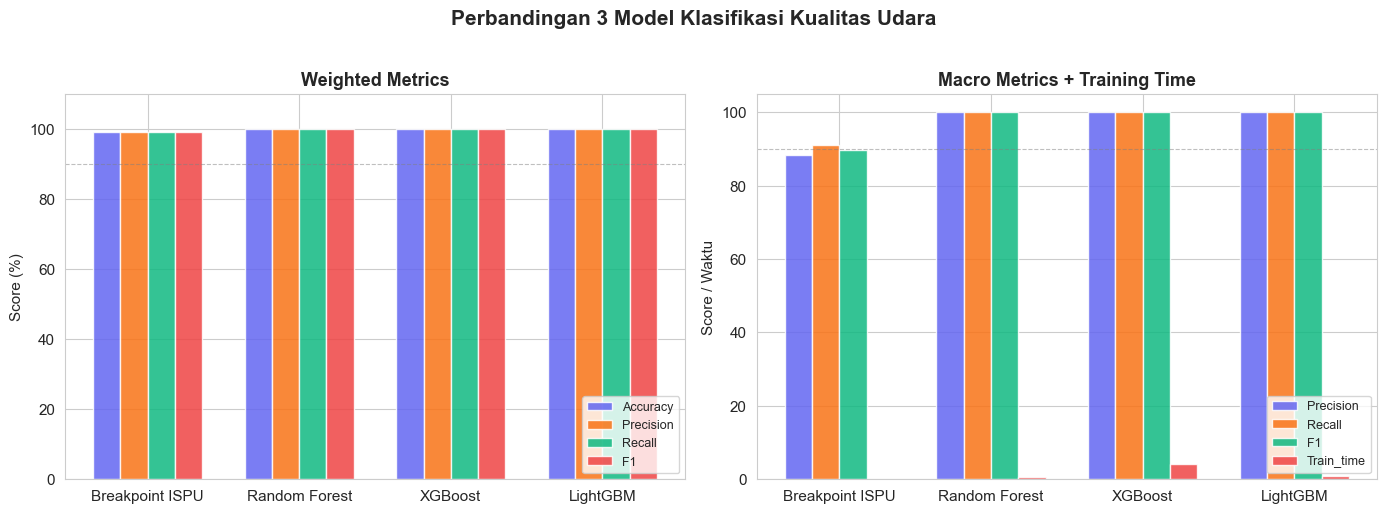

Saved: model_comparison.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_w = ['Accuracy', 'Precision_W', 'Recall_W', 'F1_W']
metrics_m = ['Precision_M', 'Recall_M', 'F1_M', 'Train_time']

x = np.arange(len(results))
width = 0.18

colors = ['#6366f1', '#f97316', '#10b981', '#ef4444']

for i, metric in enumerate(metrics_w):
    vals = [r[metric] for r in results]
    axes[0].bar(x + i*width, vals, width, label=metric.replace('_W',''), color=colors[i], alpha=0.85)

axes[0].set_xticks(x + 1.5*width)
axes[0].set_xticklabels([r['Model'] for r in results], fontsize=11)
axes[0].set_ylabel('Score (%)')
axes[0].set_title('Weighted Metrics', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 110)
axes[0].legend(fontsize=9, loc='lower right')
axes[0].axhline(y=90, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)

for i, metric in enumerate(metrics_m):
    vals = [r[metric] for r in results]
    axes[1].bar(x + i*width, vals, width, label=metric.replace('_M',''), color=colors[i], alpha=0.85)

axes[1].set_xticks(x + 1.5*width)
axes[1].set_xticklabels([r['Model'] for r in results], fontsize=11)
axes[1].set_ylabel('Score / Waktu')
axes[1].set_title('Macro Metrics + Training Time', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9, loc='lower right')
axes[1].axhline(y=90, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)

plt.suptitle('Perbandingan 3 Model Klasifikasi Kualitas Udara', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison.png")

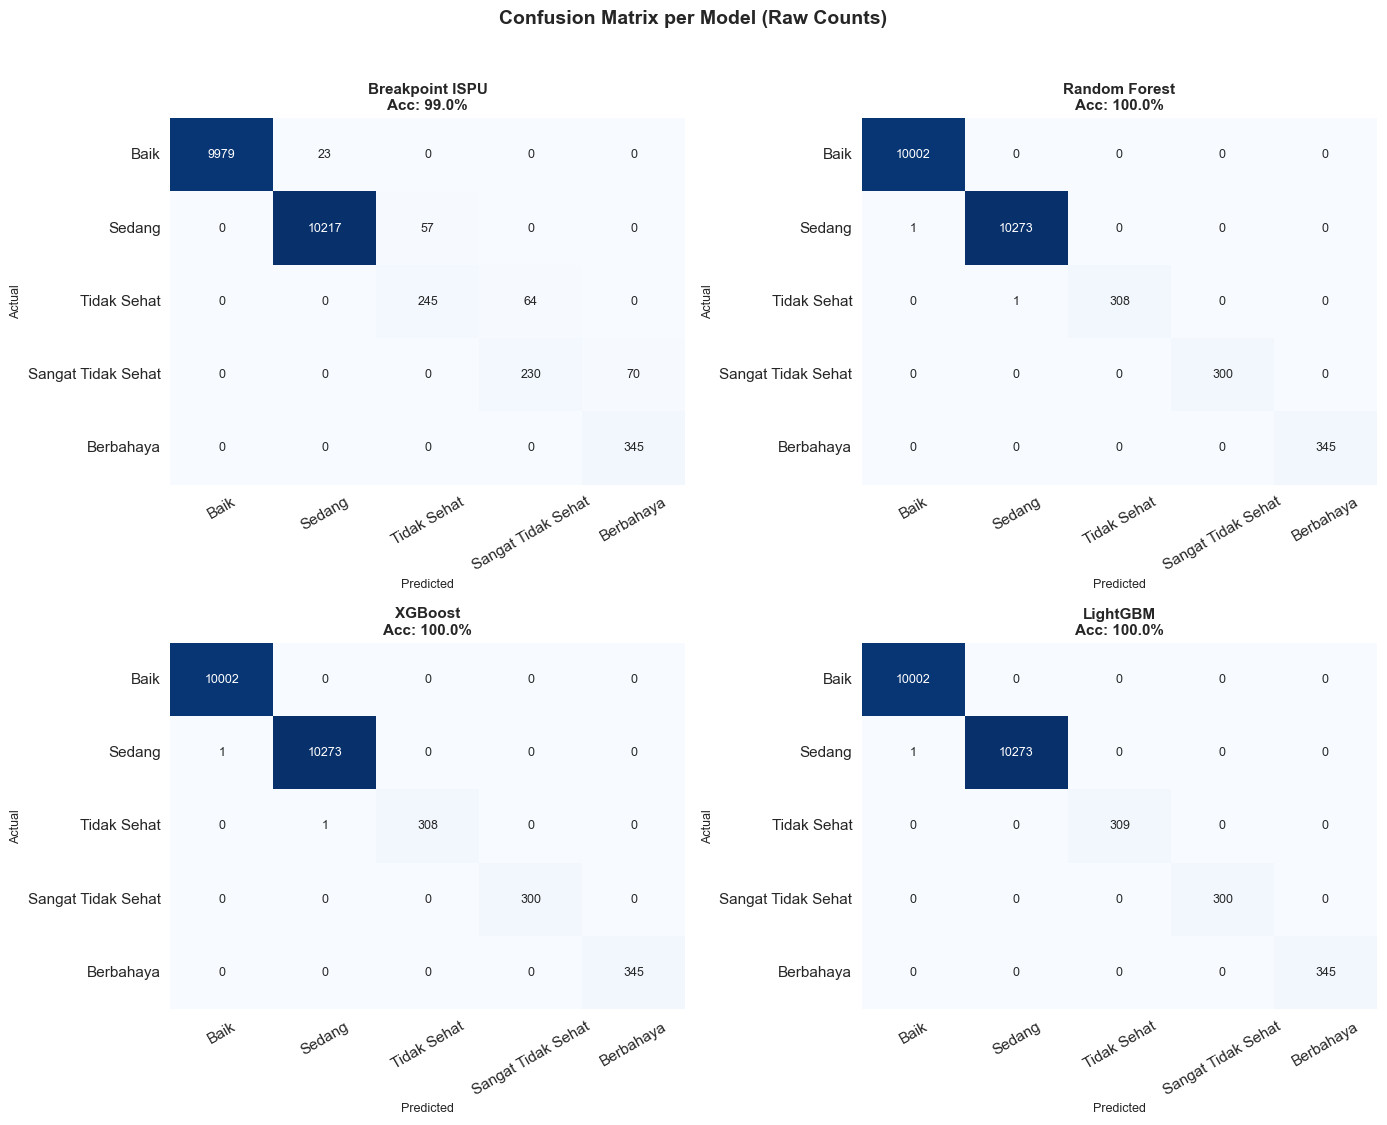

Saved: confusion_matrices.png


In [10]:
n_models = len(results)
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes_flat = axes.flatten()

for i, r in enumerate(results):
    sns.heatmap(r['CM'], annot=True, fmt='d', cmap='Blues', ax=axes_flat[i],
                xticklabels=LABELS, yticklabels=LABELS,
                annot_kws={'size': 9}, cbar=False)
    axes_flat[i].set_title(f"{r['Model']}\nAcc: {r['Accuracy']:.1f}%", fontsize=11, fontweight='bold')
    axes_flat[i].set_xlabel('Predicted', fontsize=9)
    axes_flat[i].set_ylabel('Actual', fontsize=9)
    axes_flat[i].tick_params(axis='x', rotation=30)

for j in range(i+1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle('Confusion Matrix per Model (Raw Counts)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices.png")

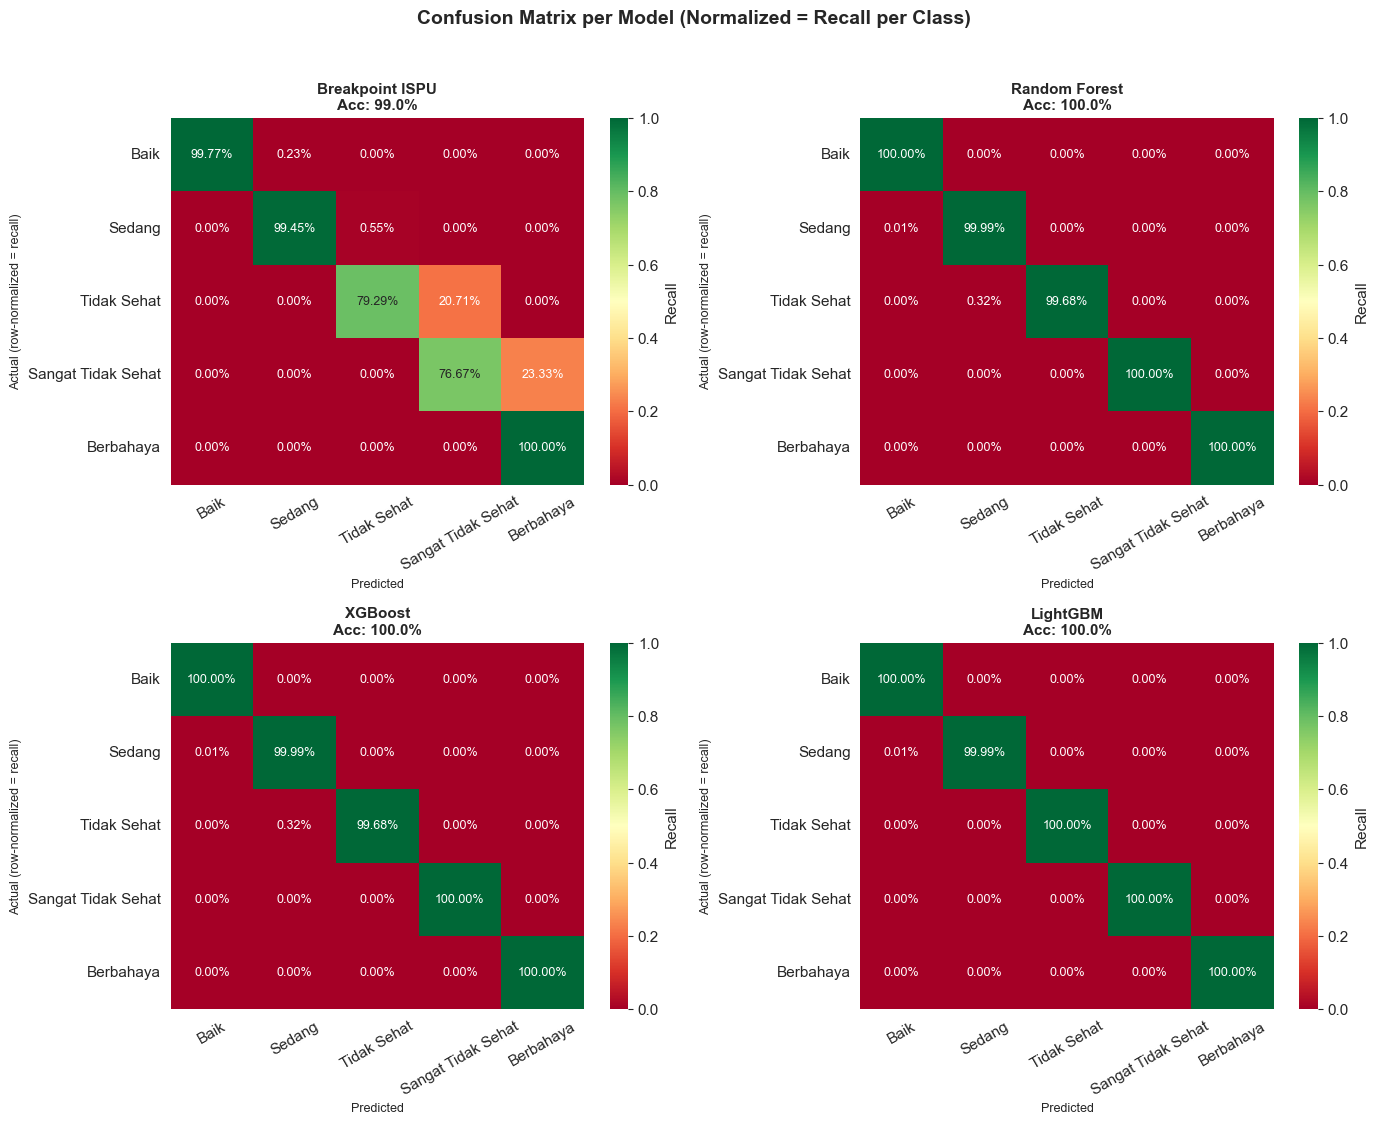

Saved: confusion_matrices_norm.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes_flat = axes.flatten()

for i, r in enumerate(results):
    cm_norm = r['CM'].astype('float') / r['CM'].sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdYlGn', ax=axes_flat[i],
                xticklabels=LABELS, yticklabels=LABELS,
                annot_kws={'size': 9}, vmin=0, vmax=1, cbar_kws={'label': 'Recall'})
    axes_flat[i].set_title(f"{r['Model']}\nAcc: {r['Accuracy']:.1f}%", fontsize=11, fontweight='bold')
    axes_flat[i].set_xlabel('Predicted', fontsize=9)
    axes_flat[i].set_ylabel('Actual (row-normalized = recall)', fontsize=9)
    axes_flat[i].tick_params(axis='x', rotation=30)

for j in range(i+1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle('Confusion Matrix per Model (Normalized = Recall per Class)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices_norm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices_norm.png")

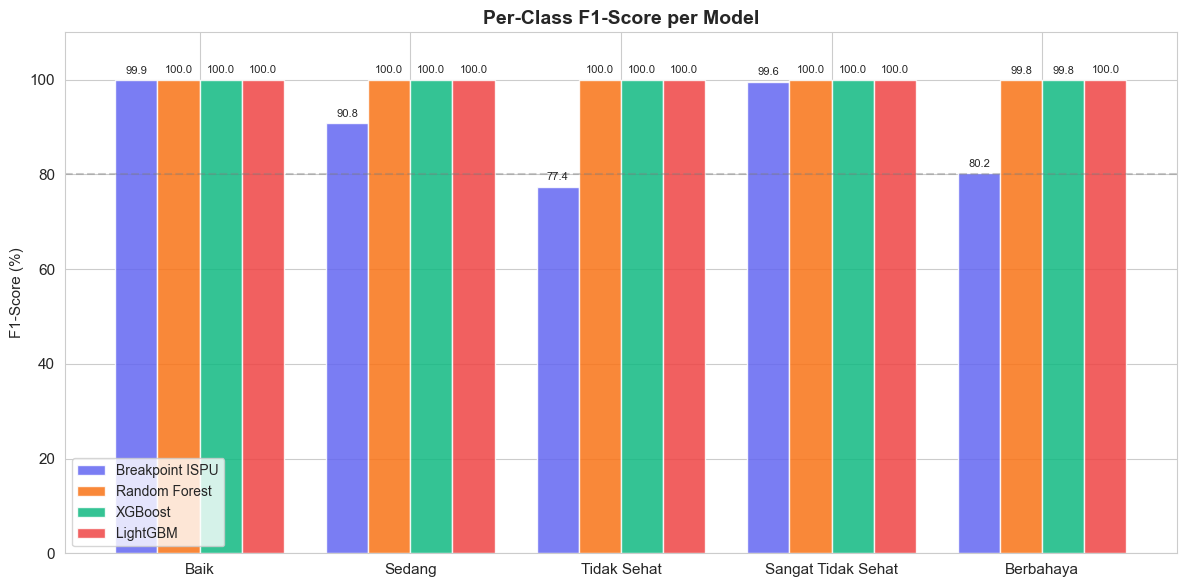

Saved: per_class_f1.png


In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(LABELS))
n_models = len(results)
width = 0.8 / n_models
colors = ['#6366f1', '#f97316', '#10b981', '#ef4444'][:n_models]

for i, r in enumerate(results):
    f1_vals = [r['PerClass'][lbl]['f1'] * 100 for lbl in LABELS]
    bars = ax.bar(x + i*width - 0.4 + width/2, f1_vals, width,
                  label=r['Model'], color=colors[i], alpha=0.85)
    for bar, val in zip(bars, f1_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(LABELS, fontsize=11)
ax.set_ylabel('F1-Score (%)', fontsize=11)
ax.set_title('Per-Class F1-Score per Model', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 110)
ax.axhline(y=80, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: per_class_f1.png")

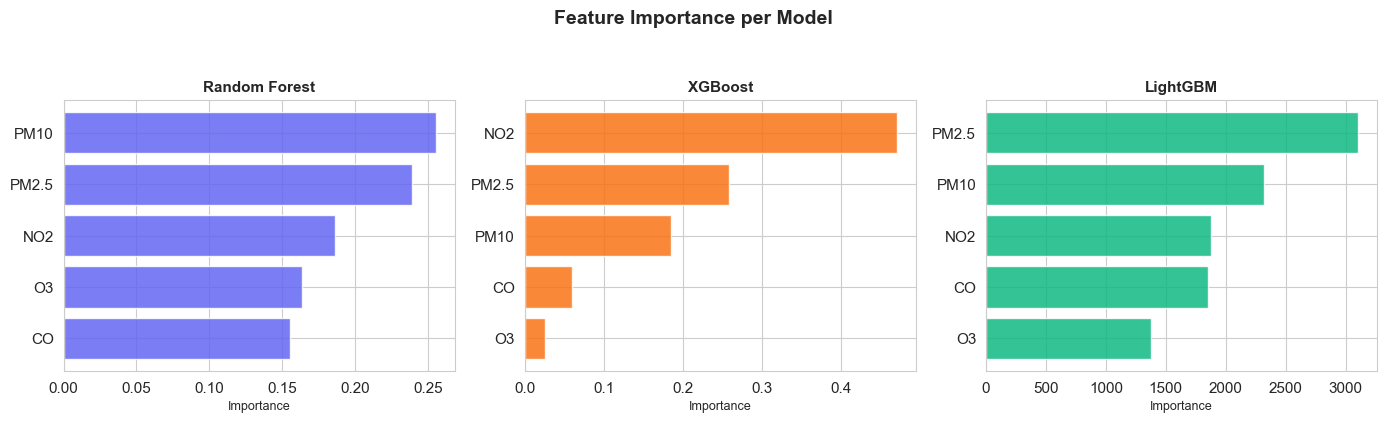

Saved: feature_importance.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, name in enumerate(MODELS.keys()):
    model = trained_models[name]
    if hasattr(model, 'feature_importances_'):
        imp = pd.DataFrame({'Feature': FEATURES, 'Importance': model.feature_importances_})
        imp = imp.sort_values('Importance', ascending=True)
        axes[i].barh(imp['Feature'], imp['Importance'], color=['#6366f1','#f97316','#10b981','#ef4444','#8b5cf6'][i % 5], alpha=0.85)
    else:
        axes[i].text(0.5, 0.5, 'N/A', ha='center', va='center', fontsize=14, transform=axes[i].transAxes)
    axes[i].set_title(f'{name}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Importance', fontsize=9)

plt.suptitle('Feature Importance per Model', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")

In [14]:
best_acc = max(results, key=lambda r: r['Accuracy'])
best_f1_w = max(results, key=lambda r: r['F1_W'])
best_f1_m = max(results, key=lambda r: r['F1_M'])
fastest = min(results, key=lambda r: r['Train_time'])

# Cari model dengan F1 tertinggi di kelas minoritas (Tidak Sehat / Sangat Tidak Sehat / Berbahaya)
minority_classes = ['Tidak Sehat', 'Sangat Tidak Sehat', 'Berbahaya']
def avg_minority_f1(r):
    return np.mean([r['PerClass'][c]['f1'] for c in minority_classes])
best_minority = max(results, key=avg_minority_f1)

print("="*60)
print("REKOMENDASI MODEL")
print("="*60)
print(f"\n  Akurasi Tertinggi : {best_acc['Model']} ({best_acc['Accuracy']:.2f}%)")
print(f"  F1 Weighted Tertinggi: {best_f1_w['Model']} ({best_f1_w['F1_W']:.2f}%)")
print(f"  F1 Macro Tertinggi: {best_f1_m['Model']} ({best_f1_m['F1_M']:.2f}%)")
print(f"  F1 Minoritas Rerata Tertinggi: {best_minority['Model']} ({avg_minority_f1(best_minority)*100:.2f}%)")
print(f"  Training Tercepat: {fastest['Model']} ({fastest['Train_time']:.3f}s)")

# Winner: prioritaskan F1 minoritas, lalu F1 macro
winner = best_minority['Model'] if best_minority != best_acc else best_f1_m['Model']
print(f"\n  REKOMENDASI AKHIR: {winner}")
print(f"  Alasan: F1 minoritas ({avg_minority_f1(best_minority)*100:.2f}%) +")
print(f"           F1 macro ({best_f1_m['F1_M']:.2f}%) seimbang")

REKOMENDASI MODEL

  Akurasi Tertinggi : LightGBM (100.00%)
  F1 Weighted Tertinggi: LightGBM (100.00%)
  F1 Macro Tertinggi: LightGBM (100.00%)
  F1 Minoritas Rerata Tertinggi: LightGBM (100.00%)
  Training Tercepat: Breakpoint ISPU (0.000s)

  REKOMENDASI AKHIR: LightGBM
  Alasan: F1 minoritas (100.00%) +
           F1 macro (100.00%) seimbang


In [15]:
best_model_name = winner
best_model = trained_models[best_model_name]

joblib.dump(best_model, f"air_quality_classifier_{best_model_name.replace(' ','_').lower()}.pkl")
print(f"Best model saved: air_quality_classifier_{best_model_name.replace(' ','_').lower()}.pkl")

import json
summary = {
    "best_model": best_model_name,
    "accuracy": best_acc['Accuracy'],
    "f1_weighted": best_f1_w['F1_W'],
    "f1_macro": best_f1_m['F1_M'],
    "all_results": [
        {k: (v.tolist() if hasattr(v,'tolist') else v) for k,v in r.items() if k != 'CM'}
        for r in results
    ]
}
with open("classification_comparison.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Summary saved: classification_comparison.json")

Best model saved: air_quality_classifier_lightgbm.pkl
Summary saved: classification_comparison.json
